# Blinkit Data Analytics — Customer analysis
DuckDB SQL + Python | Yash Prajapati

## 1. Setup

### 1.1 Libraries

In [1]:
import warnings, math, textwrap
warnings.filterwarnings('ignore')
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams.update({'figure.figsize':(10,4.5),'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.5 | pandas 3.0.2 | numpy 2.4.4


### 1.2 Load cleaned workbook

In [2]:
XLSX = 'data/Blinkit_analysis_new.xlsx'
book = pd.read_excel(XLSX, sheet_name=None)
geo = pd.read_csv('data/city_state_zone.csv')
for name, df in book.items():
    print(f'{name:28s} {df.shape[0]:>6,} rows  {df.shape[1]:>3} cols')

Data_Quality_Report              46 rows    3 cols
Orders_Customer_Info          5,000 rows   16 cols
Orders_Raw_Archive            5,000 rows   23 cols
Order_Line_Items              5,000 rows   14 cols
Delivery_Performance          5,000 rows    8 cols
Customer_Feedback             5,000 rows    8 cols
Customers                     2,500 rows   11 cols
Products                        268 rows   10 cols
Inventory_Analysis              268 rows   18 cols
Data_Dictionary                  44 rows    4 cols
Reference_Parameters             11 rows    5 cols
Relational_Diagram                0 rows    0 cols
Pivot_Payment_Method              7 rows    7 cols
Pivot_Customer_Segment            7 rows    5 cols
Pivot_Category_Sales             14 rows    4 cols
Pivot_Monthly_Trend              24 rows    6 cols
Pivot_Area_Delivery              23 rows    6 cols
Pivot_Inventory_Movement          6 rows    7 cols
Pivot_Category_Stock             14 rows    8 cols


### 1.3 Create DuckDB database and load tables

In [3]:
con = duckdb.connect('blinkit.duckdb')
load = {'orders_src':'Orders_Raw_Archive','items_src':'Order_Line_Items','delivery_src':'Delivery_Performance',
        'feedback_src':'Customer_Feedback','customers_src':'Customers','products_src':'Products','inventory_src':'Inventory_Analysis'}
for tbl, sheet in load.items():
    df = book[sheet].copy()
    df.columns = [c.strip() for c in df.columns]
    con.register('tmp_df', df)
    con.execute(f'CREATE OR REPLACE TABLE {tbl} AS SELECT * FROM tmp_df')
con.register('geo_df', geo)
con.execute('CREATE OR REPLACE TABLE geo AS SELECT * FROM geo_df')
con.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY table_name").df()

,table_name,estimated_size
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268


### 1.4 Typed analysis views

In [4]:
con.execute('''
CREATE OR REPLACE VIEW orders AS
SELECT order_id, customer_id,
       strptime(order_date, '%d-%m-%Y %H:%M')              AS order_ts,
       CAST(strptime(order_date, '%d-%m-%Y %H:%M') AS DATE) AS order_date,
       strptime(promised_delivery_time, '%d-%m-%Y %H:%M')   AS promised_ts,
       strptime(actual_delivery_time,  '%d-%m-%Y %H:%M')    AS actual_ts,
       delivery_status, order_total, payment_method, delivery_partner_id, store_id,
       CAST(delivery_time_minutes AS INTEGER)               AS delay_min,
       distance_km, reasons_if_delayed, customer_name,
       trim(area) AS area, pincode, customer_segment,
       CAST(registration_date AS DATE)                      AS registration_date,
       order_day_of_week, order_time_slot, order_value_segment,
       CASE WHEN is_weekend = 'Yes' THEN 1 ELSE 0 END       AS is_weekend
FROM orders_src ''')

con.execute('''
CREATE OR REPLACE VIEW items AS
SELECT order_id, product_id, quantity, unit_price, product_name, category, brand,
       price, mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level, line_total,
       line_total * margin_percentage / 100.0 AS margin_value
FROM items_src ''')

con.execute('''
CREATE OR REPLACE VIEW feedback AS
SELECT feedback_id, order_id, customer_id, rating, feedback_category, sentiment,
       CAST(feedback_date AS DATE) AS feedback_date
FROM feedback_src ''')

con.execute('''
CREATE OR REPLACE VIEW f_sales AS
SELECT o.order_id, o.customer_id, o.order_ts, o.order_date,
       date_trunc('month', o.order_date)  AS order_month,
       extract(hour FROM o.order_ts)      AS order_hour,
       o.order_day_of_week, o.is_weekend, o.order_time_slot, o.order_value_segment,
       o.payment_method, o.customer_segment, o.registration_date, o.customer_name,
       o.area, g.state, g.zone, g.city_tier,
       i.product_id, i.product_name, i.category, i.brand,
       i.quantity, i.line_total AS revenue, i.margin_value, i.margin_percentage,
       i.price, i.mrp, i.shelf_life_days,
       o.delay_min, o.distance_km, o.delivery_status,
       CASE WHEN o.delivery_status = 'On Time' THEN 1 ELSE 0 END AS is_on_time_status,
       CASE WHEN o.delay_min > 0 THEN 1 ELSE 0 END               AS is_late_minutes,
       f.rating, f.sentiment, f.feedback_category
FROM orders o
JOIN items i    ON i.order_id = o.order_id
LEFT JOIN geo g ON g.area     = o.area
LEFT JOIN feedback f ON f.order_id = o.order_id ''')

con.execute('SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT order_id) AS orders, MIN(order_date) AS first_day, MAX(order_date) AS last_day FROM f_sales').df()

,fact_rows,orders,first_day,last_day
0,5000,5000,2023-03-16,2024-11-04


### 1.5 Query helper

In [5]:
def q(sql, con=con):
    return con.execute(textwrap.dedent(sql)).df()

def pct(x, n):
    return round(100.0 * x / n, 2) if n else 0.0

q('SELECT COUNT(*) AS rows_in_fact_view FROM f_sales')

,rows_in_fact_view
0,5000


### Chart colours

In [6]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'

## 4. Customer analysis

### 4.1 Customer base summary

In [7]:
q('''
WITH c AS (
  SELECT customer_id, COUNT(DISTINCT order_id) AS orders, SUM(revenue) AS spend,
         MIN(order_date) AS first_order, MAX(order_date) AS last_order
  FROM f_sales GROUP BY 1)
SELECT (SELECT COUNT(*) FROM customers_src)               AS registered_customers,
       COUNT(*)                                           AS customers_who_ordered,
       COUNT(*) FILTER (WHERE orders = 1)                 AS one_order_only,
       COUNT(*) FILTER (WHERE orders >= 2)                AS repeat_customers,
       round(100.0 * COUNT(*) FILTER (WHERE orders >= 2) / COUNT(*), 2) AS repeat_rate_pct,
       round(AVG(orders), 2)                              AS avg_orders_per_customer,
       round(AVG(spend), 2)                               AS avg_spend_per_customer,
       round(SUM(spend) FILTER (WHERE orders >= 2) * 100.0 / SUM(spend), 2) AS repeat_revenue_share_pct
FROM c ''')

,registered_customers,customers_who_ordered,one_order_only,repeat_customers,repeat_rate_pct,avg_orders_per_customer,avg_spend_per_customer,repeat_revenue_share_pct
0,2500,2172,680,1492,68.69,2.30,"2,289.33",86.74


### 4.2 Distribution of orders per customer

In [8]:
q('''
WITH c AS (SELECT customer_id, COUNT(DISTINCT order_id) AS orders, SUM(revenue) AS spend FROM f_sales GROUP BY 1)
SELECT orders AS orders_placed, COUNT(*) AS customers,
       round(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS customer_share_pct,
       round(SUM(spend), 0) AS revenue,
       round(100 * SUM(spend) / SUM(SUM(spend)) OVER (), 2) AS revenue_share_pct
FROM c GROUP BY orders ORDER BY orders ''')

,orders_placed,customers,customer_share_pct,revenue,revenue_share_pct
0,1,680,31.31,"659,315.00",13.26
1,2,686,31.58,"1,377,284.00",27.70
2,3,451,20.76,"1,342,203.00",26.99
3,4,234,10.77,"946,597.00",19.04
4,5,82,3.78,"400,895.00",8.06
5,6,28,1.29,"167,163.00",3.36
6,7,8,0.37,"54,394.00",1.09
7,8,2,0.09,"14,449.00",0.29
8,9,1,0.05,"10,116.00",0.20


### 4.3 Top 15 customers by spend

In [9]:
q('''
SELECT RANK() OVER (ORDER BY SUM(revenue) DESC) AS rnk,
       any_value(customer_name) AS customer, customer_id,
       any_value(state) AS state, any_value(customer_segment) AS label,
       COUNT(DISTINCT order_id) AS orders, round(SUM(revenue), 0) AS spend,
       round(AVG(revenue), 0) AS avg_order, MAX(order_date) AS last_order
FROM f_sales GROUP BY customer_id ORDER BY spend DESC LIMIT 15 ''')

,rnk,customer,customer_id,state,label,orders,spend,avg_order,last_order
0,1,Odika Kannan,25128143,Telangana,Premium,7,"10,533.00","1,505.00",2024-01-27
1,2,Nidhi Sha,77869660,Gujarat,Premium,9,"10,116.00","1,124.00",2024-09-08
2,3,Dev Bal,12272282,Rajasthan,Regular,5,"9,925.00","1,985.00",2024-10-07
3,4,Lipika Kumer,4597433,Andhra Pradesh,Inactive,6,"9,554.00","1,592.00",2024-08-26
4,5,Leena Deol,33331259,Bihar,Inactive,4,"9,404.00","2,351.00",2024-06-11
5,6,Ayaan Rege,14472401,Kerala,Regular,4,"9,276.00","2,319.00",2024-06-24
6,7,Zinal Dhawan,85561151,Uttar Pradesh,Regular,4,"9,269.00","2,317.00",2024-01-10
7,8,Jacob Lad,22800586,Karnataka,New,4,"9,237.00","2,309.00",2024-03-06
8,9,Wishi Varughese,34668988,Maharashtra,Inactive,4,"9,161.00","2,290.00",2024-09-27
9,10,Anvi Savant,13760839,Assam,Premium,5,"9,114.00","1,823.00",2024-06-10


### 4.4 Customer revenue concentration by decile

In [10]:
q('''
WITH c AS (SELECT customer_id, SUM(revenue) AS spend FROM f_sales GROUP BY 1),
d AS (SELECT customer_id, spend, NTILE(10) OVER (ORDER BY spend DESC) AS decile FROM c)
SELECT decile, COUNT(*) AS customers, round(SUM(spend), 0) AS revenue,
       round(100 * SUM(spend) / SUM(SUM(spend)) OVER (), 2) AS revenue_share_pct,
       round(100 * SUM(SUM(spend)) OVER (ORDER BY decile ROWS UNBOUNDED PRECEDING) / SUM(SUM(spend)) OVER (), 2) AS cumulative_share_pct
FROM d GROUP BY decile ORDER BY decile ''')

,decile,customers,revenue,revenue_share_pct,cumulative_share_pct
0,1,218,"1,293,729.00",26.02,26.02
1,2,218,"875,134.00",17.60,43.62
2,3,217,"698,776.00",14.05,57.67
3,4,217,"575,848.00",11.58,69.25
4,5,217,"473,719.00",9.53,78.78
5,6,217,"384,796.00",7.74,86.52
6,7,217,"291,648.00",5.87,92.38
7,8,217,"200,292.00",4.03,96.41
8,9,217,"129,302.00",2.60,99.01
9,10,217,"49,170.00",0.99,100.00


### 4.5 New versus repeat revenue by month

In [11]:
q('''
WITH first_order AS (SELECT customer_id, MIN(order_date) AS first_date FROM f_sales GROUP BY 1),
tagged AS (
  SELECT s.order_month, s.revenue,
         CASE WHEN s.order_date = f.first_date THEN 'new' ELSE 'repeat' END AS customer_type
  FROM f_sales s JOIN first_order f ON f.customer_id = s.customer_id)
SELECT strftime(order_month, '%Y-%m') AS month,
       round(SUM(revenue) FILTER (WHERE customer_type = 'new'), 0)    AS new_customer_revenue,
       round(SUM(revenue) FILTER (WHERE customer_type = 'repeat'), 0) AS repeat_customer_revenue,
       round(100 * SUM(revenue) FILTER (WHERE customer_type = 'repeat') / SUM(revenue), 2) AS repeat_share_pct
FROM tagged GROUP BY order_month ORDER BY order_month ''')

,month,new_customer_revenue,repeat_customer_revenue,repeat_share_pct
0,2023-03,"109,083.00","1,907.00",1.72
1,2023-04,"224,414.00","24,969.00",10.01
2,2023-05,"231,032.00","38,413.00",14.26
3,2023-06,"179,469.00","54,204.00",23.20
4,2023-07,"166,695.00","70,366.00",29.68
5,2023-08,"180,161.00","123,351.00",40.64
6,2023-09,"140,222.00","137,364.00",49.49
7,2023-10,"139,884.00","123,976.00",46.99
8,2023-11,"116,777.00","144,698.00",55.34
9,2023-12,"96,124.00","157,504.00",62.10


### 4.6 Gap between consecutive orders

In [12]:
q('''
WITH seq AS (
  SELECT customer_id, order_date,
         ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY order_date) AS order_no,
         LAG(order_date) OVER (PARTITION BY customer_id ORDER BY order_date) AS prev_date
  FROM (SELECT DISTINCT customer_id, order_date FROM f_sales)),
gaps AS (SELECT order_no, date_diff('day', prev_date, order_date) AS gap_days FROM seq WHERE prev_date IS NOT NULL)
SELECT order_no AS order_number, COUNT(*) AS transitions,
       round(AVG(gap_days), 1) AS avg_gap_days,
       round(median(gap_days), 1) AS median_gap_days,
       MIN(gap_days) AS min_gap, MAX(gap_days) AS max_gap
FROM gaps WHERE order_no <= 6 GROUP BY order_no ORDER BY order_no ''')

,order_number,transitions,avg_gap_days,median_gap_days,min_gap,max_gap
0,2,1490,164.50,135.00,1,545
1,3,804,131.80,99.50,1,532
2,4,351,113.20,86.00,1,357
3,5,121,91.20,82.00,2,273
4,6,39,99.20,88.00,1,311


### 4.7 Monthly cohort retention

In [13]:
q('''
WITH first_order AS (SELECT customer_id, date_trunc('month', MIN(order_date)) AS cohort FROM f_sales GROUP BY 1),
activity AS (
  SELECT f.cohort, date_diff('month', f.cohort, s.order_month) AS month_index, s.customer_id
  FROM f_sales s JOIN first_order f ON f.customer_id = s.customer_id),
sized AS (SELECT cohort, COUNT(DISTINCT customer_id) AS cohort_size FROM activity WHERE month_index = 0 GROUP BY 1)
SELECT strftime(a.cohort, '%Y-%m') AS cohort_month, s.cohort_size,
       round(100.0 * COUNT(DISTINCT a.customer_id) FILTER (WHERE month_index = 1) / s.cohort_size, 1) AS m1_pct,
       round(100.0 * COUNT(DISTINCT a.customer_id) FILTER (WHERE month_index = 2) / s.cohort_size, 1) AS m2_pct,
       round(100.0 * COUNT(DISTINCT a.customer_id) FILTER (WHERE month_index = 3) / s.cohort_size, 1) AS m3_pct,
       round(100.0 * COUNT(DISTINCT a.customer_id) FILTER (WHERE month_index BETWEEN 4 AND 6) / s.cohort_size, 1) AS m4_m6_pct
FROM activity a JOIN sized s ON s.cohort = a.cohort
GROUP BY a.cohort, s.cohort_size ORDER BY a.cohort ''')

,cohort_month,cohort_size,m1_pct,m2_pct,m3_pct,m4_m6_pct
0,2023-03,117,11.10,8.50,3.40,26.50
1,2023-04,217,8.80,11.50,10.10,30.40
2,2023-05,233,9.40,6.00,11.60,29.60
3,2023-06,175,7.40,9.70,10.30,28.00
4,2023-07,171,9.90,7.60,11.70,25.10
5,2023-08,166,7.80,8.40,4.80,22.90
6,2023-09,137,10.20,10.20,8.80,24.10
7,2023-10,135,11.90,14.10,7.40,25.90
8,2023-11,117,10.30,12.00,6.80,29.90
9,2023-12,105,11.40,8.60,6.70,21.90


### 4.8 Recency, frequency and monetary table

In [14]:
rfm = q('''
WITH base AS (SELECT MAX(order_date) AS as_of FROM f_sales)
SELECT s.customer_id,
       date_diff('day', MAX(s.order_date), (SELECT as_of FROM base)) AS recency_days,
       COUNT(DISTINCT s.order_id)  AS frequency,
       round(SUM(s.revenue), 2)    AS monetary,
       round(AVG(s.revenue), 2)    AS avg_order_value,
       date_diff('day', MIN(s.order_date), MAX(s.order_date)) AS tenure_days,
       any_value(s.zone) AS zone, any_value(s.customer_segment) AS label
FROM f_sales s GROUP BY s.customer_id ''')
print(rfm.shape)
rfm.describe()[['recency_days','frequency','monetary','avg_order_value','tenure_days']]

(2172, 8)


,recency_days,frequency,monetary,avg_order_value,tenure_days
count,"2,172.00","2,172.00","2,172.00","2,172.00","2,172.00"
mean,206.39,2.30,"2,289.33",990.22,187.16
std,156.39,1.25,"1,713.52",577.64,178.28
min,0.00,1.00,12.32,12.32,0.00
25%,73.00,1.00,919.79,569.83,0.00
50%,170.00,2.00,"1,959.98",899.68,156.00
75%,315.25,3.00,"3,225.06","1,331.26",340.00
max,599.00,9.00,"10,533.39","2,929.65",590.00


### 4.9 Customers who never ordered

In [15]:
q('''
SELECT c.customer_segment AS label, COUNT(*) AS never_ordered
FROM customers_src c LEFT JOIN orders o ON o.customer_id = c.customer_id
WHERE o.order_id IS NULL GROUP BY 1 ORDER BY never_ordered DESC ''')

,label,never_ordered
0,New,98
1,Premium,83
2,Inactive,82
3,Regular,65


## Charts

### 16.6 Cohort retention

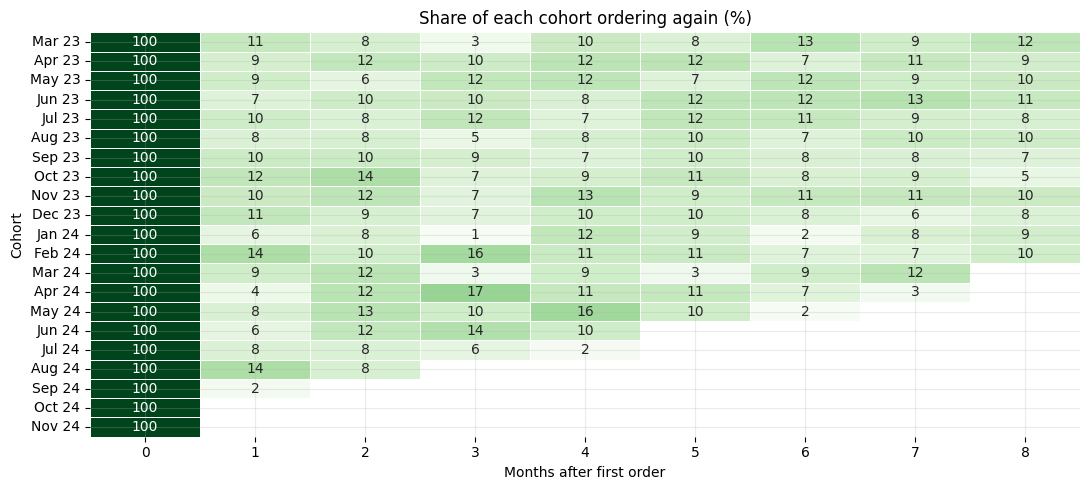

In [16]:
cohort = q('''
WITH first_order AS (SELECT customer_id, date_trunc('month', MIN(order_date)) AS cohort FROM f_sales GROUP BY 1),
activity AS (SELECT f.cohort, date_diff('month', f.cohort, s.order_month) AS month_index, s.customer_id
             FROM f_sales s JOIN first_order f ON f.customer_id = s.customer_id)
SELECT cohort, month_index, COUNT(DISTINCT customer_id) AS customers FROM activity GROUP BY 1, 2 ''')
cp = cohort.pivot(index='cohort', columns='month_index', values='customers')
cp = cp.div(cp[0], axis=0).mul(100).round(1).iloc[:, :9]
cp.index = pd.to_datetime(cp.index).strftime('%b %y')
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cp, annot=True, fmt='.0f', cmap='Greens', vmax=40, linewidths=.6, linecolor='white', cbar=False, ax=ax)
ax.set_title('Share of each cohort ordering again (%)'); ax.set_xlabel('Months after first order'); ax.set_ylabel('Cohort')
plt.tight_layout(); plt.show()